In [4]:
import pandas as pd
df = pd.read_json("Results.json")
df.head()

,TAPSE,Aortic Sinus Diameter,Left Atrial Diameter,Interventricular Septum Thickness,Left Ventricular End-Diastolic Diameter,Left Ventricular Posterior Wall Thickness,Left Ventricular End-Systolic Diameter,Ejection Fraction,Right Atrial Diameter (Horizontal),Right Ventricular Diameter (Horizontal),...,Examination Time,Left Atrial Volume Index,Pulmonary Arterial Systolic Pressure,Aortic Valve Annulus Diameter,Sinus Diameter,Sinotubular Junction Diameter,Maximum Distal Diameter,RV Area Change Fraction,TDI Tricuspid Annular s' Velocity,Average e' Velocity
0,22.0,32,37,9,45,9,28,67,32,33,...,2024-05-23 09:05:20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,25,46,10,57,10,44,54,39,38,...,2022-05-30 18:11:12,2.0,49.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,18.0,34,49,10,52,10,39,55,37,32,...,2022-12-05 14:16:58,NaN,37.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,28,47,10,53,10,42,38,34,31,...,2021-11-01 09:31:07,NaN,34.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,27,45,9,51,9,39,42,35,33,...,2021-12-02 14:28:30,NaN,30.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
y = df["Patient Category"]
X = df.select_dtypes(include=["int64", "float64"])
X = X.fillna(X.mean())

X.shape, y.shape  # 看看特征维度

((15, 27), (15,))

In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

rfc = RandomForestClassifier(n_estimators=38, random_state=42)

# 10折交叉验证
score_pre = cross_val_score(rfc, X, y, cv=7).mean()
print("基础模型的平均准确率 acc =", score_pre)

基础模型的平均准确率 acc = 0.8095238095238094


/Users/maokeyu/Desktop/ECG/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 23398 (\N{CJK UNIFIED IDEOGRAPH-5B66}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/maokeyu/Desktop/ECG/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20064 (\N{CJK UNIFIED IDEOGRAPH-4E60}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/maokeyu/Desktop/ECG/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26354 (\N{CJK UNIFIED IDEOGRAPH-66F2}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/maokeyu/Desktop/ECG/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 32447 (\N{CJK UNIFIED IDEOGRAPH-7EBF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/maokeyu/Desktop/ECG/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170:

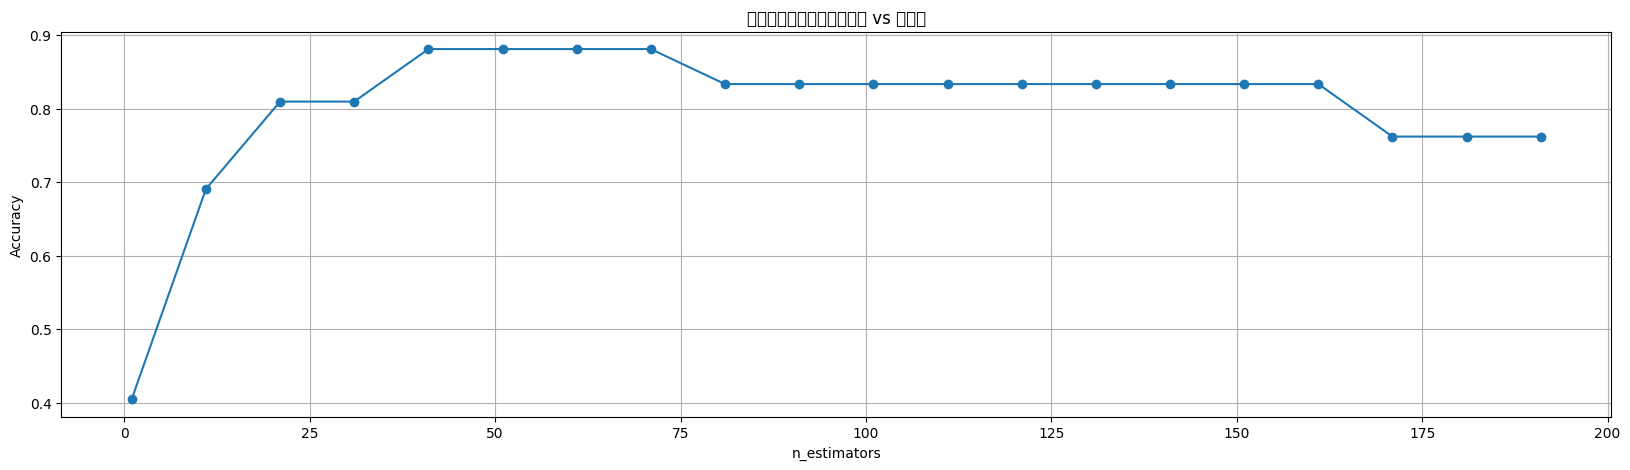

最优 n_estimators ≈ 41，准确率为：0.8810


In [12]:
import matplotlib.pyplot as plt

scorel = []
for i in range(1, 201, 10):
    clf = RandomForestClassifier(n_estimators=i, n_jobs=-1, random_state=42)
    score = cross_val_score(clf, X, y, cv=7).mean()
    scorel.append(score)

# 可视化学习曲线
plt.figure(figsize=[20,5])
plt.plot(range(1, 201, 10), scorel, marker="o")
plt.xlabel("n_estimators")
plt.ylabel("Accuracy")
plt.title("学习曲线：随机森林树数量 vs 准确率")
plt.grid(True)
plt.show()

# 找到最优值
best_score = max(scorel)
best_n = (scorel.index(best_score) * 10) + 1
print(f"最优 n_estimators ≈ {best_n}，准确率为：{best_score:.4f}")

/Users/maokeyu/Desktop/ECG/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 32454 (\N{CJK UNIFIED IDEOGRAPH-7EC6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/maokeyu/Desktop/ECG/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 35843 (\N{CJK UNIFIED IDEOGRAPH-8C03}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/maokeyu/Desktop/ECG/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 23398 (\N{CJK UNIFIED IDEOGRAPH-5B66}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/maokeyu/Desktop/ECG/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20064 (\N{CJK UNIFIED IDEOGRAPH-4E60}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/maokeyu/Desktop/ECG/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170:

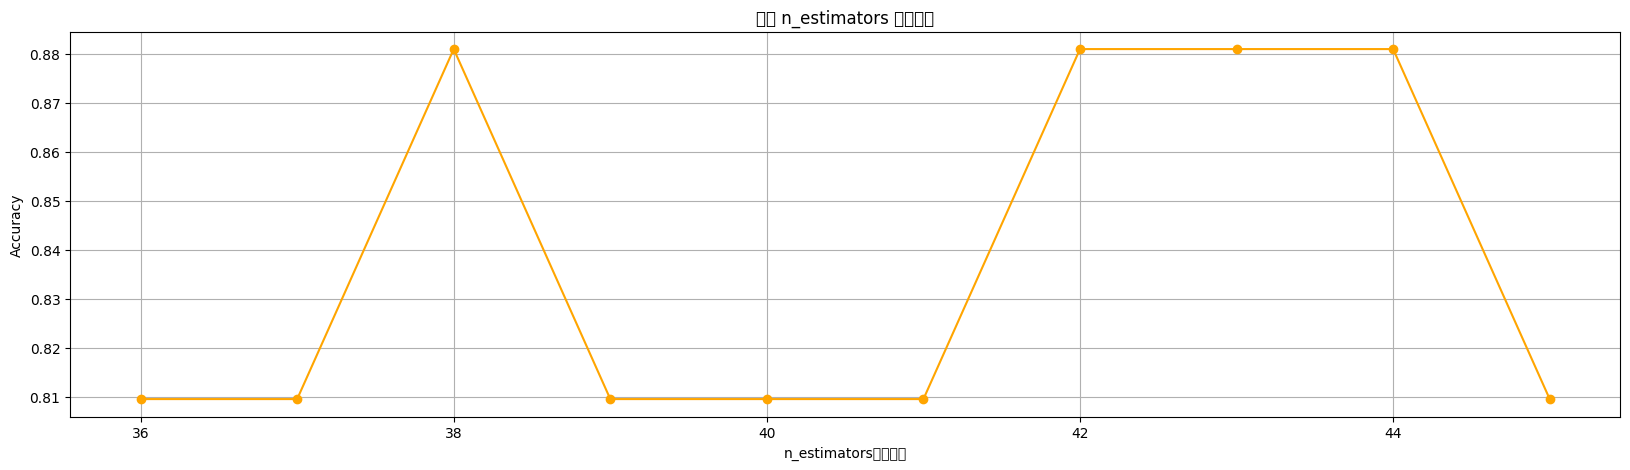

🎯 细调后最优 n_estimators = 38，准确率为：0.8810


In [13]:
scorel_fine = []
for i in range(35, 45):
    clf = RandomForestClassifier(n_estimators=i, n_jobs=-1, random_state=42)
    score = cross_val_score(clf, X, y, cv=7).mean()
    scorel_fine.append(score)

plt.figure(figsize=[20,5])
plt.plot(range(best_n - 5, best_n + 5), scorel_fine, marker="o", color='orange')
plt.xlabel("n_estimators（细调）")
plt.ylabel("Accuracy")
plt.title("细调 n_estimators 学习曲线")
plt.grid(True)
plt.show()

best_score_fine = max(scorel_fine)
best_n_fine = list(range(best_n - 5, best_n + 5))[scorel_fine.index(best_score_fine)]
print(f"🎯 细调后最优 n_estimators = {best_n_fine}，准确率为：{best_score_fine:.4f}")